In [263]:
from em_utilities import read_EMTFXML
import matplotlib.pyplot as plt
from scipy.constants import mu_0
import numpy as np

import ipyleaflet
from matplotlib import patches, collections, ticker, colors, cm

# MT Processing & Interpretation

Topics of the day:
* Review of 1D, 2D, and 3D properties of $Z$
* Calculating components of $Z$
* Processing techniques
* Interpreations
* Tipper data (if we have time)

## Dimensional characteristics of $Z$
In general for 3D we have:

$$
\begin{pmatrix}
E_x(\omega) \\ 
E_y(\omega)
\end{pmatrix} = 
\begin{pmatrix}
Z_{xx}(\omega) & Z_{xy}(\omega) \\ 
Z_{yx}(\omega) & Z_{yy}(\omega)
\end{pmatrix}
\begin{pmatrix}
H_x(\omega) \\ 
H_y(\omega)
\end{pmatrix}
$$

When the earth is 1D, we have that:
$$Z_{xx} = Z_{yy} = 0$$
$$Z_{xy} = -Z_{yx} \neq 0$$

When the earth is 2D, we have that:
$$Z_{xx} = Z_{yy} = 0$$
$$Z_{xy} \neq 0 \text{ and } Z_{yx} \neq 0 \text{ and } Z_{xy} \neq -Z_{yx}$$

> Only when the coordinate axes are alignend with strike

## Calculating Z

Take 1 row of the general 3D relationship:
$$
E_x = Z_{xx} H_x + Z_{xy} H_y
$$

The issue:
* 1 Equation
* 2 Unknowns

> There's an infinite number of valid values for $Z_{xx}, Z_{xy}$ that would satisfy the above equation for any measured $E_x, H_x, H_y$

Remember
* Our recorded data is also noisy!

### Stacking
Let's split our timeseries in half and obtain two estimates of $E_x, H_x, H_y$

\begin{align}
E_{x,1} &= Z_{xx} H_{x,1} + Z_{xy} H_{y,1} \\
E_{x,2} &= Z_{xx} H_{x,2} + Z_{xy} H_{y,2} \\
\end{align}

> 2 Equations, 2 unknowns, solvable as long as $H_{x,1}, H_{y,1}$ are not linearly realted to $H_{x,2}, H_{y,2}$, which is unlikely given they are both noisy

### Why stop at 2?
Let's split it up $N$ times!

\begin{align}
E_{x,1} &= Z_{xx} H_{x,1} + Z_{xy} H_{y,1} \\
E_{x,2} &= Z_{xx} H_{x,2} + Z_{xy} H_{y,2} \\
&\vdots\\
E_{x,N} &= Z_{xx} H_{x,N} + Z_{xy} H_{y,N} \\
\end{align}

And then solve by a Least Squares approach (but remember all of the quantities are *complex*)

#### Complex least squares solution

Let's measure the difference using $v = E_x - Z_{xx} H_x - Z_{xy} H_{y}$, and measure its [*Frobenius*](https://en.wikipedia.org/wiki/Frobenius_inner_product) norm.

$$
\phi = \sum_{i=1}^{N} <v_i, v_i> = \sum_{i=1}^{N} v_iv_i^*=\sum_{i=1}^N (E_{x,i} - Z_{xx}H_{x,i} - Z_{xy}H_{y,i})(E_{x,i} - Z_{xx}H_{x,i} - Z_{xy}H_{y,i})^*
$$

or in terms of a matrix-vector equation:

$$\phi = ||AZ_x - b||_F^2 = (AZ_{x} - b)(AZ_{x} - b)^*
$$

with
$$
A = \begin{pmatrix}
H_{x, 1} & H_{y,1}\\
H_{x, 2} & H_{y,2}\\
\vdots\\
H_{x, N} & H_{y,N}\\
\end{pmatrix},
Z_x = \begin{pmatrix}
Z_{xx}\\
Z_{xy}
\end{pmatrix},
b = \begin{pmatrix}
E_{x,1}\\
E_{x,2}\\
\vdots\\
E_{x,N}
\end{pmatrix}
$$

To minimize, take a [derivative](https://en.wikipedia.org/wiki/Wirtinger_derivatives) and set it equal to zero:
> special care must be taken because $Z_{ij}$ is a complex number, and derivatives with respect to complex numbers are not *quite* the same as derivatives with respect to real numbers

$$ d\phi = (A Z_x - b)^*: A dZ_x$$

$$ \frac{d\phi}{dZ_x} = A^T (A Z_x - b)^* =>0 $$
$$ A^T b^*=A^T (A Z_x)^*$$
$$  A^H b = A^H A Z_x$$

> $ A^H $ means $A$ conjugate tranpose

### Least squares solution:

The least squares solution is given by solving the following set of equations for $Z_{xx}$ and $Z_{xy}$:
$$
\sum E_{x,i} H_{x_i}^* =Z_{xx}\sum H_{x,i}H_{x,i}^*  + Z_{xy}\sum H_{y,i}H_{x,i}^*
$$
$$
\sum E_{x,i} H_{y_i}^* = Z_{xx}\sum H_{x,i}H_{y,i}^*  + Z_{xy}\sum H_{y,i}H_{y,i}^*
$$

### What is $\sum U_i(\omega) V_{i}^*(\omega)$ doing?
$U$ is the frequency transformed $u$

* All of our $U_i$ are just transformed pieces of $u_i$
* Multiplication in frequency domain is convolution in the time domain
* Conjugate operator in frequency domain is a time-reversal in the time domain
* $U_i V_{i}^*$ Implies we are just convolving $u$ with a reversed $v$
* Break the signal into an arbitrary number of pieces, then:

$$
\sum U_i(\omega) V_{i}^*(\omega) \propto U(\omega)V^*(\omega)
$$

* equivalent to just using the frequency spectrum $U$ of the entire time-series $u$

### Correlations
* let $<UV^*>$ represent the power spectrum of the cross-correlation $(u \star v)$ (auto-correlation if they're the same) of the two time series $u$ and $v$.
* $<H_x H_x^*> = \sum H_{x,i}(\omega) H_{x,i}^*(\omega)$ is the frequency spectrum of the [*auto-correlation*](https://en.wikipedia.org/wiki/Autocorrelation) of $h_x$
* $<H_x H_y^*> = \sum H_{x,i}(\omega) H_{y,i}^*(\omega)$ is the frequency spectrum of the [*cross-correlation*](https://en.wikipedia.org/wiki/Cross-correlation) of $h_x$ with $h_y$

### Least-squares impedace estimates
From the first row of $E=ZH$:

$$Z_{xx} = \frac{<H_yH_y^*><E_xH_x^*> - <H_yH_x*><E_xH_y^*>}{<H_xH_x^*> <H_yH_y^*> - <H_xH_y^*><H_yH_x^*>}$$
$$Z_{xy} = \frac{<H_xH_x^*><E_xH_y^*> - <H_xH_y*><E_xH_x^*>}{<H_xH_x^*> <H_yH_y^*> - <H_xH_y^*><H_yH_x^*>}$$

From the second row of $E=ZH$
$$Z_{yx} = \frac{<H_yH_y^*><E_yH_x^*> - <H_yH_x*><E_yH_y^*>}{<H_xH_x^*> <H_yH_y^*> - <H_xH_y^*><H_yH_x^*>}$$
$$Z_{yy} = \frac{<H_xH_x^*><E_yH_y^*> - <H_xH_y*><E_yH_x^*>}{<H_xH_x^*> <H_yH_y^*> - <H_xH_y^*><H_yH_x^*>}$$

### Biases from noisy data:

Cross-correlations are a measure of similarity between two signals as a function of the displacement of one relative to the other.

If $\tilde{u}$ has noise, and $\tilde{v}$ also has noise, $(\tilde{u} \star \tilde{v})$ will estimate $(u \star v )$ as:
* unbiased if the noise in each measurements are uncorrelated.
* downward biased if the noise is correlated
* upward biased if the noise is anti-correlated

* Auto-correlation $(\tilde{u} \star \tilde{u})$ will be an upward biased estimate of $(u \star u)$.


### How to fix the bias
Idea, use a remote MT station as a reference for $H_x^*$ and $H_y^*$.

Remote site should be
* far enough away such that the noise is uncorrelated
* close enough that the signals are still correlated

## Remote Referencing

Replace all $H_x^*$ and $H_y^*$ with a remote station's $H_{x,RR}^*$ and $H_{y,RR}^*$ when estimating $Z_{ij}$ 

Remote referencing is the most common form of collecting MT data.

* That's why the GP department has two ADU-07e's

## Processing
Processing MT data usually follows these steps:


### Getting data
Collect voltages from voltage dipoles and H field receivers and calculate their field quanitites.

* E-field
    * Divide $\Delta V$ by the distance to get $E$, usually in units of nV/km.
* H-field
    * coils usually have a calibration curve relating V to T (or A/m).
        * These are the impulse response of the coil, represents its variable sensitivity to different frequency components of $H$
        * Thus "deconvolve" the measured response with the coil's impulse response
            * Just a division of the measured signal with the coil's calibration curve in the frequency domain

### Calculating impedances

There are many options on determining the impedane tensor components from your time series data

1. "Brute" stacking of $Z_{ij}$ time series splits at a single station.
1. Remote referencing one station against another.
1. Selective stacking: Basically brute stacking using weights, putting less weight on outliers.
1. Coherency Thresholding: Only choose time-series for estimations based on how coherent the signals are.
1. Combinations of the above.

Most of the time the impedance calculation is done using a remote reference combined with some form of selective stacking
> Stacking also gives you estimates of the standard deviation of the estimated $Z_{ij}$ at each proceseed frequency.

### Frequency Binning

Then responses for specific frequencies are calculated as the average response along specific bands of frequencies:

### Summary
1. Transform recorded data from measured voltages to Electric fields and Magnetic Fields
2. Calculate Impedance components
3. Average Impedance's within frequency bins

> Then interpet your data

In [3]:
T, Z, dat_dict = read_EMTFXML('resources/USArray.COP24.2018.r1.xml', return_dict=True)

In [14]:
dat_dict['EM_TF']['Site']['Name']

'Tiny Town, CO, USA'

In [19]:
lat = float(dat_dict['EM_TF']['Site']['Location']['Latitude'])
lon = float(dat_dict['EM_TF']['Site']['Location']['Longitude'])
center = (lat, lon)
mapp = ipyleaflet.Map(center=center, zoom=12)
mapp.add(ipyleaflet.Marker(location=center, draggable=False, title=dat_dict['EM_TF']['Site']['Name']));

In [20]:
mapp

Map(center=[39.606023, -105.210201], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

## Interpretation

Before inversion:
#### Apparent calculations
* You can calculate apparent conductivities/resisitivites and phase from $Z$ (compare agaist half-spaces)

In [21]:
omega = 2 * np.pi / T
sigma_a = 2*np.pi/T[:, None, None] * mu_0 * 1/np.abs(Z)**2
rho_a = 1.0/sigma_a

In [272]:
rho_a[-1], T[-1]

(array([[2072.40394139,  950.0654524 ],
        [6129.10721674, 2119.81095173]]),
 np.float64(18724.57))

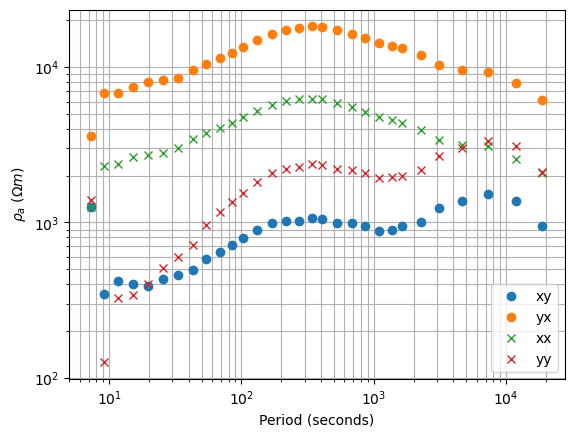

In [217]:
plt.loglog(T, rho_a[:, 0, 1], linestyle="", marker="o", label='xy')
plt.loglog(T, rho_a[:, 1, 0], linestyle="", marker="o", label='yx')
plt.loglog(T, rho_a[:, 0, 0], linestyle="", marker="x", label='xx')
plt.loglog(T, rho_a[:, 1, 1], linestyle="", marker="x", label='yy')
plt.grid(which='both')
plt.xlabel("Period (seconds)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()

* Can Identify 1D structures:
    * If $Z$ has zeros for the diagonal and $Z_{xy}=-Z_{yx}$

> For this example, clearly it is not 1D, (Z_{xx} and Z_{yy} are not zero)

* In 2D $Z_{xx}$ and $Z_{yy}$ are zero only when an axis is aligned with strike!
    * Rotate $Z$ to find an apparent strike direction!
    * Maximize $Z_{xy}^2 + Z_{yx}^2$
      $$
      \tan(4\alpha) = \frac{(Z_{xx} - Z_{yy})(Z_{xy} + Z_{yx})^* + (Z_{xx} - Z_{yy})^*(Z_{xy} + Z_{yx})}{|Z_{xx} - Z_{yy}|^2 - |Z_{xy} + Z_{yx}|^2}
      $$
    * Find strike direction as a function of frequency and position

In [67]:
def apparent_strike(Z):
    Z_xx = Z[..., 0, 0]
    Z_xy = Z[..., 0, 1]
    Z_yx = Z[..., 1, 0]
    Z_yy = Z[..., 1, 1]

    diff1 = Z_xx - Z_yy
    diff2 = Z_xy - Z_yx
    sum1 = Z_xx + Z_yy
    sum2 = Z_xy + Z_yx

    four_alpha = np.arctan2((sum2 * diff1.conjugate() + sum2.conjugate() * diff1).real, np.abs(diff1)**2 - np.abs(sum2)**2)
    return four_alpha / 4

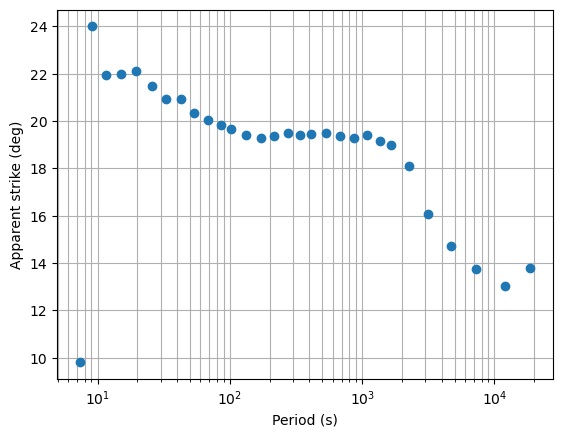

In [79]:
th_app = apparent_strike(Z)
plt.semilogx(T, th_app * 180/np.pi, marker='o', linestyle="")
plt.xlabel("Period (s)")
plt.ylabel("Apparent strike (deg)")
plt.grid(which="both")

In [94]:
th = th_app[11]+0.1
R = np.array([[np.cos(th), -np.sin(th)],[np.sin(th), np.cos(th)]])
Zp = R.T @ Z[11] @ R
np.abs(Zp[0,1])**2 + np.abs(Zp[1,0])**2

np.float64(0.0008346678274587978)

* Calculate the skew of $Z$ to as a measure of dimensionality:
$$skew = \frac{Z_{xx} + Z_{yy}}{Z_{xy} - Z_{yx}}$$

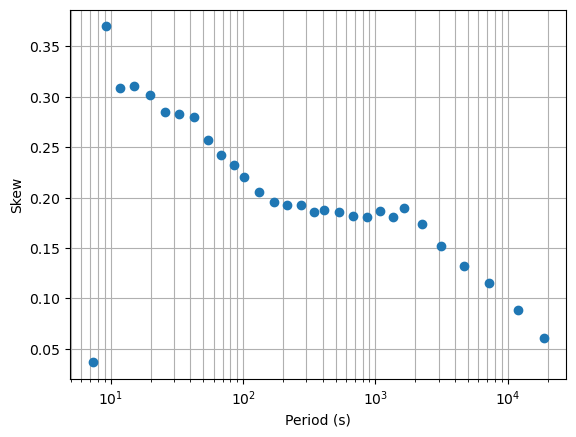

In [170]:
def skew(Z):
    Z_xx = Z[..., 0, 0]
    Z_xy = Z[..., 0, 1]
    Z_yx = Z[..., 1, 0]
    Z_yy = Z[..., 1, 1]

    return (Z_xx + Z_yy)/(Z_xy - Z_yx)

plt.semilogx(T, np.abs(skew(Z)), marker='o', linestyle="")
plt.xlabel("Period (s)")
plt.ylabel("Skew")
plt.grid(which="both")

> $Z_{xy}-Z_{yx}$ gets larger at longer periods and $Z_{xx} + Z_{yy}$ get's smaller

### Phase Tensors:
Plot Z as an ellipse, comparing the the Real and Imaginary parts of $Z$.

Extension of the phase of a complex number to the phase of a complex Tensor

$$\Phi = Re(Z)^{-1} Im(z)$$

* Calculate its skew angle $\beta = \frac{1}{2}\tan^{-1}\left(\frac{\Phi_{12} - \Phi_{21}}{\Phi_{11} + \Phi_{22}}\right)$
* And its Singular Values $\Phi_{max}$ and $\Phi_{min}$
* Plot as an ellipse!

#### Phase Tensor Properties:
* 1D structures make circles
* 2D and 3D structures make ellipses aligned with local strike

In [171]:
phi = np.linalg.solve(Z.real, Z.imag)

In [273]:
phi_11 = phi[..., 0, 0]
phi_12 = phi[..., 0, 1]
phi_21 = phi[..., 1, 0]
phi_22 = phi[..., 1, 1]

beta = np.arctan2((phi_12 - phi_21),(phi_11 + phi_22))
vals = np.linalg.svdvals(phi)

Text(0.5, 0, 'Period (S)')

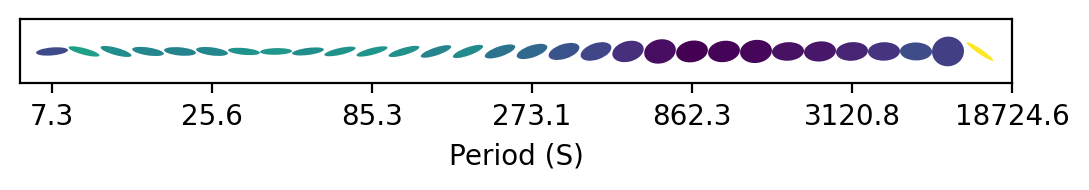

In [275]:
ells = []
for i in range(len(beta)):
    width, height = vals[i]
    height = height/width
    ells.append(patches.Ellipse([i, 0], 1, height, angle=beta[i]*180/np.pi))

cmap = plt.get_cmap('viridis')
norm = colors.LogNorm()
ells = collections.PatchCollection(ells, facecolors=plt.get_cmap('viridis')(norm(vals[:, 0])))

plt.figure(dpi=200)
ax = plt.gca()
ax.add_collection(ells)
ax.set_xlim([-1, len(beta)])

ticks_x = ticker.FuncFormatter(lambda x, pos: f'{T[min(int(x), len(T)-1)]:.1f}')
ax.xaxis.set_major_formatter(ticks_x)

ax.set_ylim([-1, 1])
ax.set_yticks([])
ax.set_aspect(1)
ax.set_xlabel('Period (S)')

Displaying phase tesors at a constant frequency in horizontal positions

![Phase Tensors](https://oup.silverchair-cdn.com/oup/backfile/Content_public/Journal/gji/158/2/10.1111/j.1365-246X.2004.02281.x/3/m_158-2-457-fig007.jpeg?Expires=1739934496&Signature=Xwe-Tk3JbJmlWOK6dx4QyXwveC4buEYcES2yJMHm0Ag-BVCYPOqZotlX4p8G3Oe0o4pwt4cuzqumg5dYSbj8xyBd5yowtTso7UpDHa7bZ4WJDo0YzB7XhRRwMPh1WUWoQEGGT0Y4Dl~RQ3yjMV1ljdb5OSSnK7oz6VdZntPLNaDIukPbMFg~wYOYxl9Wc~VSr-FTafAWD7NvTfJtxshFvK0YmsZN99sJvCA1lJaE~AxHJ~tCzTLwc~x60UCgnQhmCw0u6bGprbblMSTketXHsbU48pV7UFYANSY2aFM6R01v4NKIHmti5sE4HeBZT4SdkM2ngRvhRH1~LgDShIbuNQ__&Key-Pair-Id=APKAIE5G5CRDK6RD3PGA)

Or as a function of period "like a sounding"

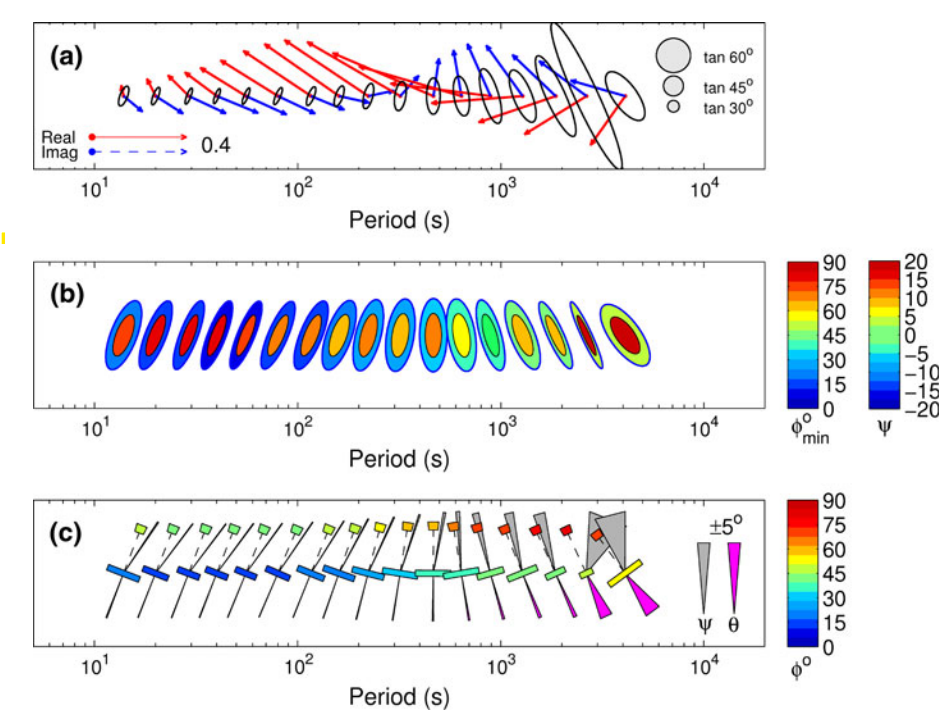